In [1]:
import numpy as np
import matplotlib.pyplot as plt

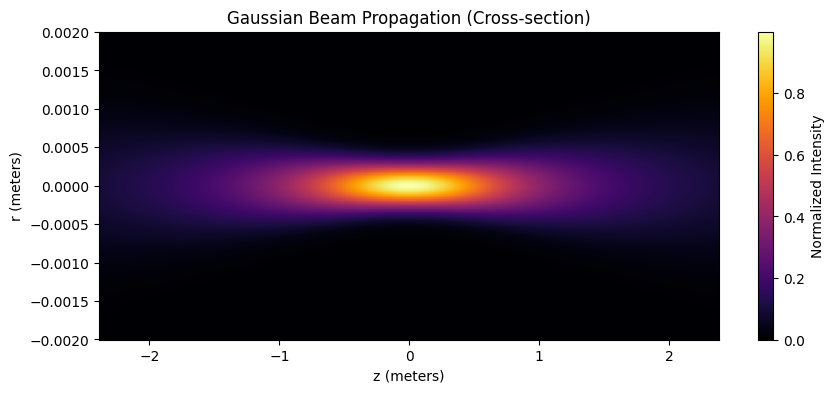

In [2]:
lam = 633e-9 # Wavelength
w_0 = 0.4e-3 # Waist radius
z_r = np.pi * w_0**2 / lam

z = np.linspace(-3*z_r, 3*z_r, 500) # Propagation distance
r = np.linspace(-2e-3, 2e-3, 500) # Radial distance
Z, R = np.meshgrid(z, r)

# Calculate Beam Width and Intensity
w_z = w_0 * np.sqrt(1 + (Z/z_r)**2)
I = (w_0 / w_z)**2 * np.exp(-2 * R**2 / w_z**2)


plt.figure(figsize=(10, 4))
plt.pcolormesh(Z, R, I, cmap='inferno', shading='auto')
plt.colorbar(label='Normalized Intensity')
plt.title("Gaussian Beam Propagation (Cross-section)")
plt.xlabel("z (meters)")
plt.ylabel("r (meters)")
plt.show()

In [3]:
# Through lens

def matrix_transform(q_in, A, B, C, D):
    return (A * q_in + B) / (C * q_in + D)

q_init = 1j * z_r

d = 0.1
q_after = matrix_transform(q_init, 1, d, 0, 1)

f = 0.05 # Focal of lens
q_f = matrix_transform(q_after, 1, 0, -1/f, 1)

inv_q = 1 / q_f
new_w = np.sqrt(-lam / (np.pi * np.imag(inv_q)))
print(f"New spot size after lens: {new_w*1e3:.3f} mm")

New spot size after lens: 0.403 mm
